In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Alzheimer_Balanced.zip to Alzheimer_Balanced.zip


In [ ]:
import os

dataset_path = "/content/dataset"

print("Contents of dataset_path after extraction:")
for root, dirs, files in os.walk(dataset_path):
    print(f"Directory: {root}, Number of files: {len(files)}")

Contents of dataset_path after extraction:


In [ ]:
import pandas as pd
import os
import zipfile # Import zipfile

dataset_path = "/content/dataset"

# --- Start of added code for extraction ---
# Dynamically get the zip file name from the uploaded dictionary
# Assuming only one file is uploaded for the dataset
zip_filename = list(uploaded.keys())[0]
zip_file_path = os.path.join("/content/", zip_filename)

# Create the dataset directory if it doesn't exist
os.makedirs(dataset_path, exist_ok=True)

# Check if the dataset has already been extracted to avoid re-extracting
# We can check for the presence of one of the class folders, e.g., "NonDemented"
if not os.path.exists(os.path.join(dataset_path, "NonDemented")):
    print(f"Extracting {zip_file_path} to {dataset_path}...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")
# --- End of added code for extraction ---


class_names = {
    "NonDemented":0,
    "VeryMildDemented":1,
    "MildDemented":2,
    "ModerateDemented":3
}


image_paths = []
labels = []


for folder, label in class_names.items():

    folder_path = os.path.join(dataset_path, folder)

    for image in os.listdir(folder_path):

        image_paths.append(
            os.path.join(folder_path,image)
        )

        labels.append(label)


df = pd.DataFrame({
    "filename":image_paths,
    "label":labels
})


print(df.head())

print("\nClass distribution:")
print(df.label.value_counts())

Extracting /content/Alzheimer_Balanced.zip to /content/dataset...
Extraction complete.
                                      filename  label
0  /content/dataset/NonDemented/nonDem1949.jpg      0
1  /content/dataset/NonDemented/nonDem1984.jpg      0
2   /content/dataset/NonDemented/nonDem608.jpg      0
3   /content/dataset/NonDemented/nonDem866.jpg      0
4   /content/dataset/NonDemented/nonDem171.jpg      0

Class distribution:
label
0    1000
1    1000
2    1000
3    1000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=42, stratify=train_df["label"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 2560
Validation size: 640
Test size: 800


In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=5,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
)

val_data = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
)

test_data = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False,
)

Found 2560 validated image filenames.
Found 640 validated image filenames.
Found 800 validated image filenames.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model

# Load base model
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(256, 256, 3))

# Attach classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
# Freeze base model
base_model.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Training Stage 1 (Top Layers Only) ---")
stage1_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

--- Training Stage 1 (Top Layers Only) ---
Epoch 1/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 78s 679ms/step - accuracy: 0.5938 - loss: 0.9524 - val_accuracy: 0.3344 - val_loss: 1.1993
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 526ms/step - accuracy: 0.7309 - loss: 0.6154 - val_accuracy: 0.6766 - val_loss: 0.8019
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 531ms/step - accuracy: 0.7867 - loss: 0.5152 - val_accuracy: 0.7422 - val_loss: 0.6396
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 524ms/step - accuracy: 0.8195 - loss: 0.4532 - val_accuracy: 0.7797 - val_loss: 0.5806
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 518ms/step - accuracy: 0.8344 - loss: 0.4048 - val_accuracy: 0.7719 - val_loss: 0.5528
Epoch 6/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 523ms/step - accuracy: 0.8668 - loss: 0.3435 - val_accuracy: 0.7641 - val_loss: 0.5222
Epoch 7/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 517ms/step - accuracy: 0.8656 - loss: 0.3441 - val_accuracy: 0.8094 - val_loss: 0.4721
Epoch 8/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 543ms/step - accurac

In [ ]:
# Unfreeze base model
base_model.trainable = True

# Freeze bottom layers, unfreeze top 50 layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("--- Training Stage 2 (Fine-Tuning Base Model) ---")
stage2_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks
)

--- Training Stage 2 (Fine-Tuning Base Model) ---
Epoch 1/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 94s 677ms/step - accuracy: 0.8641 - loss: 0.3517 - val_accuracy: 0.7734 - val_loss: 0.5411 - learning_rate: 2.0000e-05
Epoch 2/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 532ms/step - accuracy: 0.8758 - loss: 0.3168 - val_accuracy: 0.7797 - val_loss: 0.5109 - learning_rate: 2.0000e-05
Epoch 3/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 535ms/step - accuracy: 0.9047 - loss: 0.2784 - val_accuracy: 0.7984 - val_loss: 0.4736 - learning_rate: 2.0000e-05
Epoch 4/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 528ms/step - accuracy: 0.8977 - loss: 0.2780 - val_accuracy: 0.7937 - val_loss: 0.4675 - learning_rate: 2.0000e-05
Epoch 5/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 515ms/step - accuracy: 0.9035 - loss: 0.2562 - val_accuracy: 0.7984 - val_loss: 0.4601 - learning_rate: 2.0000e-05
Epoch 6/25
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 528ms/step - accuracy: 0.9238 - loss: 0.2305 - val_accuracy: 0.7937 - val_loss: 0.4547 - learning_rate: 2.0000e-05
Epoch 7/

In [ ]:
print("--- Evaluating Final Model on Test Set ---")
loss, accuracy = model.evaluate(test_data)
print(f"\nFinal Test Accuracy: {accuracy * 100:.2f}%")

--- Evaluating Final Model on Test Set ---
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.8087 - loss: 0.4987

Final Test Accuracy: 80.87%


In [ ]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix


prediction=model.predict(test_data)


predicted_classes=np.argmax(
    prediction,
    axis=1
)


true_classes=test_df["label"]


classes=[
    "NonDemented",
    "VeryMildDemented",
    "MildDemented",
    "ModerateDemented"
]


print(
classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
)
)


print(
confusion_matrix(
    true_classes,
    predicted_classes
)
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step
                  precision    recall  f1-score   support

     NonDemented       0.75      0.76      0.75       200
VeryMildDemented       0.72      0.59      0.65       200
    MildDemented       0.77      0.88      0.82       200
ModerateDemented       1.00      1.00      1.00       200

        accuracy                           0.81       800
       macro avg       0.81      0.81      0.81       800
    weighted avg       0.81      0.81      0.81       800

[[152  30  18   0]
 [ 44 119  36   1]
 [  8  16 176   0]
 [  0   0   0 200]]


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mri.jpeg to mri.jpeg


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.densenet import preprocess_input
from PIL import Image
import numpy as np
import io

# Assuming 'uploaded' is a dictionary containing the uploaded image
# Get the filename from the uploaded dictionary
img_filename = list(uploaded.keys())[0]
img_data = uploaded[img_filename]

# Open and resize the image
img = Image.open(io.BytesIO(img_data)).resize(IMG_SIZE)

# Convert image to array and preprocess
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


In [ ]:
prediction=model.predict(img_array)


predicted_class=np.argmax(prediction)


classes=[
    "Non Demented",
    "Very Mild Demented",
    "Mild Demented",
    "Moderate Demented"
]


print(
"Predicted:",
classes[predicted_class]
)


print(
"Confidence:",
prediction[0][predicted_class]*100,
"%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Predicted: Very Mild Demented
Confidence: 99.89864 %


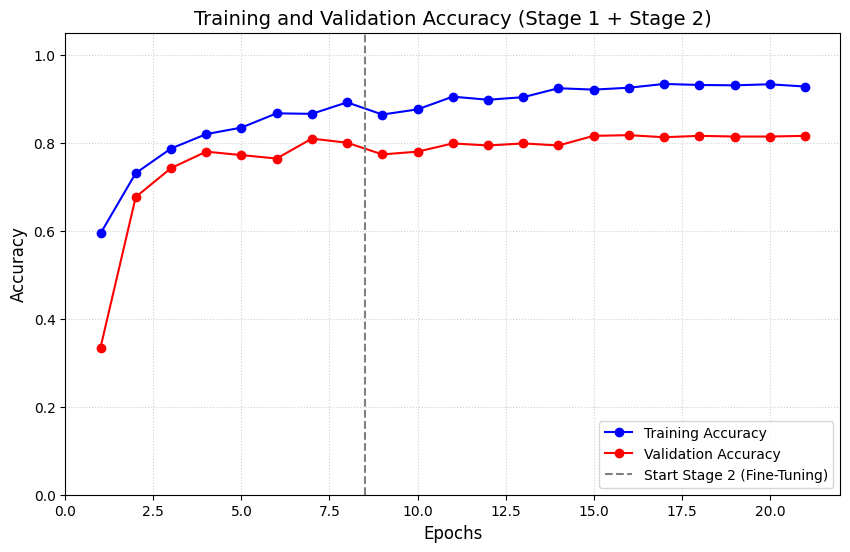

In [ ]:
import matplotlib.pyplot as plt

# Combine Stage 1 and Stage 2 accuracy values
acc = stage1_history.history['accuracy'] + stage2_history.history['accuracy']
val_acc = stage1_history.history['val_accuracy'] + stage2_history.history['val_accuracy']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')

# Draw a vertical line where Stage 2 (Fine-Tuning) started
stage1_length = len(stage1_history.history['accuracy'])
plt.axvline(x=stage1_length + 0.5, color='gray', linestyle='--', label='Start Stage 2 (Fine-Tuning)')

plt.title('Training and Validation Accuracy (Stage 1 + Stage 2)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim([0, 1.05])
plt.show()

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # Helps boundary cases
    metrics=["accuracy"]
)